<a href="https://colab.research.google.com/github/aleksandrabegovic/apple_sentiment_analiza/blob/main/SentimentMicrosoft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip -q install yfinance

import pandas as pd
import numpy as np
import yfinance as yf
#Potrebne biblioteke za dalje analize.

In [3]:
from google.colab import files
uploaded = files.upload()
#Podaci su učitani u okruženje, nakon čega su dalje obrađeni.

Saving apple_news_data.csv to apple_news_data.csv


In [4]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.shape, df.columns
#Prikaz osnovnih informacija o datasetu, broj redova, broj kolona, kao i informacija o tome koje sve kolone postoje.

((29752, 10),
 Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
        'sentiment_polarity', 'sentiment_neg', 'sentiment_neu',
        'sentiment_pos'],
       dtype='object'))

In [5]:
df.head(5)
#Prikaz prvih 5 redova, kako bismo videli sa kojim podacima radimo.

,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos
0,2024-11-27T16:39:00+00:00,Berkshire Stock Hits Record Even as Company Re...,"Warren Buffett’s caution, his advancing age, a...",https://finance.yahoo.com/m/f5df3aa4-364b-31d6...,"0R2V.IL, AAPL.BA, AAPL.MX, AAPL.NEO, AAPL.SN, ...",NaN,0.0,0.0,1.0,0.0
1,2024-11-26T00:00:00+00:00,What Is a Stock Market Index?,What Is a Stock Market Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, MSFT.US",NaN,0.0,0.0,1.0,0.0
2,2024-11-26T00:00:00+00:00,"Could Investing $1,000 in Apple Make You a Mil...","Could Investing $1,000 in Apple Make You a Mil...",https://www.fool.com/investing/2024/11/26/coul...,AAPL.US,NaN,0.0,0.0,1.0,0.0
3,2024-11-26T00:00:00+00:00,Dow Jones Industrial Average,Dow Jones Industrial Average,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMGN.US, AMZN.US, CSCO.US, GOOG.US, G...",NaN,0.0,0.0,1.0,0.0
4,2024-11-26T00:00:00+00:00,What Is the S&P 500 Index?,What Is the S&P 500 Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, GOOG.US, GOOGL.US, META.US, ...",NaN,0.0,0.0,1.0,0.0


In [6]:
df["date"] = pd.to_datetime(df["date"])
df[["date"]].head()
# Konverzija kolone 'date' u datetime format radi vremenskog
# usklađivanja finansijskih vesti sa podacima o cenama akcija.

,date
0,2024-11-27 16:39:00+00:00
1,2024-11-26 00:00:00+00:00
2,2024-11-26 00:00:00+00:00
3,2024-11-26 00:00:00+00:00
4,2024-11-26 00:00:00+00:00


In [7]:
msft_df = df[df["symbols"].str.contains("MSFT.US", na=False)].copy()

print("Broj MSFT.US vesti:", len(msft_df))

Broj MSFT.US vesti: 3334


In [8]:
msft_df["year"] = pd.to_datetime(msft_df["date"]).dt.year
msft_df["year"].value_counts().sort_index()

,count
year,
2017,1
2020,68
2021,1171
2022,745
2023,831
2024,518


In [11]:
random_news = msft_df.sample(1)

print("DATUM:", random_news["date"].values[0])
print("NASLOV:", random_news["title"].values[0])
print("TEKST:", random_news["content"].values[0])

DATUM: 2024-03-30T09:48:00.000000000
NASLOV: Which "Magnificent Seven" Stocks Are Attracting More of the Big Money?
TEKST: When most people buy a company's shares, it doesn't affect the stock's overall momentum very much. Individual investors are small fish in a big ocean. But there are some big fish whose moves can significantly impact a stock's momentum.

Institutional investors include large organizations such as investment firms, insurers, and pension funds. They're sometimes called the "big money" because of the massive size of their investments.

As you might imagine, institutional investors own major stakes in the so-called "Magnificent Seven" stocks. That's to be expected since these are some of the biggest companies in the world. But which Magnificent Seven stocks are attracting more of the big money?

The biggest winners

Roughly 65.5% of Nvidia's (NASDAQ: NVDA) shares are owned by institutional investors. The big money has moved into the chipmaker more than any other Magnifi

In [12]:
!pip install yfinance

In [13]:
import yfinance as yf
import pandas as pd

In [14]:


msft_prices = yf.download("MSFT", start="2017-01-01", end="2024-12-31")

msft_prices = msft_prices.reset_index()

msft_prices = msft_prices.rename(columns={
    "Date": "date",
    "Close": "close"
})

/tmp/ipykernel_3844/3369005200.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  msft_prices = yf.download("MSFT", start="2017-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [15]:
msft_df["date"] = pd.to_datetime(msft_df["date"]).dt.date
msft_prices["date"] = pd.to_datetime(msft_prices["date"]).dt.date

In [16]:
msft_df["date"] = pd.to_datetime(msft_df["date"])
msft_prices["date"] = pd.to_datetime(msft_prices["date"])

In [17]:
msft_df = msft_df.sort_values("date")
msft_prices = msft_prices.sort_values("date")

In [18]:
msft_prices.columns = msft_prices.columns.droplevel(1)
msft_prices = msft_prices.rename(columns={"Close": "close"})

In [19]:
import pandas as pd

# 1) priprema price tabele
msft_prices = msft_prices.sort_values("date").copy()
msft_prices["close_t"] = msft_prices["close"]
msft_prices["close_t1"] = msft_prices["close"].shift(-1)
msft_prices["open_t1"] = msft_prices["Open"].shift(-1)
msft_prices["open_t2"] = msft_prices["Open"].shift(-2)

msft_prices["avg_t"] = (
    msft_prices["Open"] +
    msft_prices["High"] +
    msft_prices["Low"] +
    msft_prices["close"]
) / 4

msft_prices["avg_t1"] = msft_prices["avg_t"].shift(-1)

# 2) merge vesti,sledeći trading dan
msft_merged = pd.merge_asof(
    msft_df.sort_values("date"),
    msft_prices[["date", "close_t", "close_t1", "open_t1", "open_t2", "avg_t", "avg_t1"]],
    on="date",
    direction="forward"
)

# 3) prinosi

# close-close: od današnjeg close do sutrašnjeg close
msft_merged["return_close_close"] = (
    msft_merged["close_t1"] - msft_merged["close_t"]
) / msft_merged["close_t"]

# open-open: od sutrašnjeg open do preksutrašnjeg open
msft_merged["return_open_open"] = (
    msft_merged["open_t2"] - msft_merged["open_t1"]
) / msft_merged["open_t1"]

# open-close: od sutrašnjeg open do sutrašnjeg close
msft_merged["return_open_close"] = (
    msft_merged["close_t1"] - msft_merged["open_t1"]
) / msft_merged["open_t1"]

# avg-avg
msft_merged["return_avg_avg"] = (
    msft_merged["avg_t1"] - msft_merged["avg_t"]
) / msft_merged["avg_t"]

In [21]:
msft_merged[["date", "title", "close_t", "close_t1", "return_close_close","return_open_open","return_open_close","return_avg_avg"]].head()

,date,title,close_t,close_t1,return_close_close,return_open_open,return_open_close,return_avg_avg
0,2017-10-05,New Research: Key Drivers of Growth for Micros...,69.364067,69.391434,0.000395,0.003965,0.004361,0.003209
1,2020-03-23,3 ETFs To Short The Dow,129.168289,140.909134,0.090896,0.035896,0.031930,0.067536
2,2020-03-30,Buying What the Fed Buys,152.203568,149.809769,-0.015728,-0.040151,-0.010602,0.024339
3,2020-04-23,Dow Jones Today: Microscopic Gains Under Loomi...,162.832947,165.806183,0.018259,0.026328,0.014472,0.000550
4,2020-04-24,How to Invest Your Stimulus Check,165.806183,165.331238,-0.002864,-0.005663,-0.014384,0.012950


In [22]:
d = pd.to_datetime("2021-07-28")

msft_merged[msft_merged["date"].dt.date == d.date()][["close_t","close_t1"]].drop_duplicates()

,close_t,close_t1
804,275.279297,275.548676


In [32]:
msft_merged["direction_close_close"] = msft_merged["return_close_close"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

msft_merged["direction_open_open"] = msft_merged["return_open_open"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

msft_merged["direction_open_close"] = msft_merged["return_open_close"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

msft_merged["direction_avg_avg"] = msft_merged["return_avg_avg"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

In [33]:
msft_merged["direction_close_close"].value_counts()

,count
direction_close_close,
UP,1701
DOWN,1633


In [34]:
msft_merged["direction_open_open"].value_counts()

,count
direction_open_open,
UP,1711
DOWN,1623


In [35]:
msft_merged["direction_open_close"].value_counts()

,count
direction_open_close,
UP,1762
DOWN,1572


In [36]:
msft_merged["direction_avg_avg"].value_counts()

,count
direction_avg_avg,
UP,1825
DOWN,1509


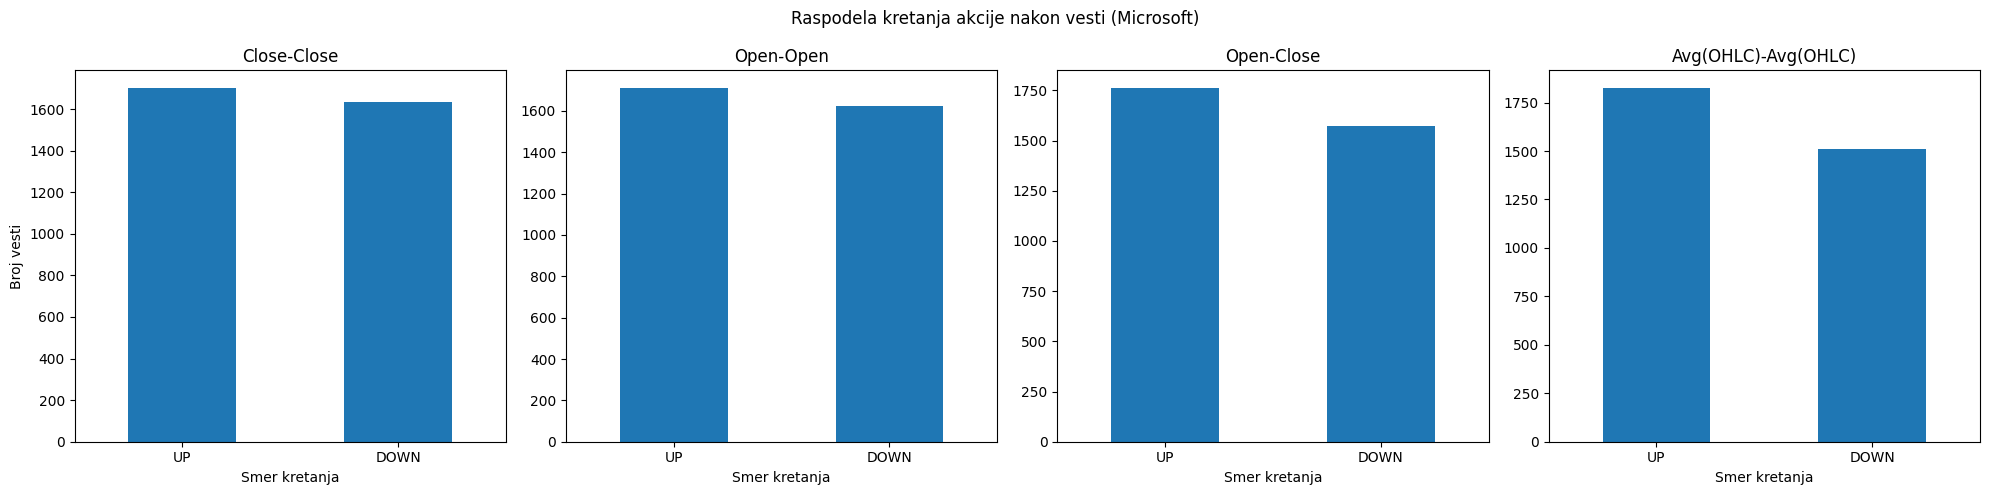

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20,5))

# close-close
msft_merged["direction_close_close"].value_counts().plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Close-Close")
axes[0].set_xlabel("Smer kretanja")
axes[0].set_ylabel("Broj vesti")
axes[0].tick_params(axis='x', rotation=0)

# open-open
msft_merged["direction_open_open"].value_counts().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Open-Open")
axes[1].set_xlabel("Smer kretanja")
axes[1].tick_params(axis='x', rotation=0)

# open-close
msft_merged["direction_open_close"].value_counts().plot(
    kind="bar", ax=axes[2]
)
axes[2].set_title("Open-Close")
axes[2].set_xlabel("Smer kretanja")
axes[2].tick_params(axis='x', rotation=0)

# avg-avg
msft_merged["direction_avg_avg"].value_counts().plot(
    kind="bar", ax=axes[3]
)
axes[3].set_title("Avg(OHLC)-Avg(OHLC)")
axes[3].set_xlabel("Smer kretanja")
axes[3].tick_params(axis='x', rotation=0)

plt.suptitle("Raspodela kretanja akcije nakon vesti (Microsoft)")
plt.tight_layout()
plt.show()

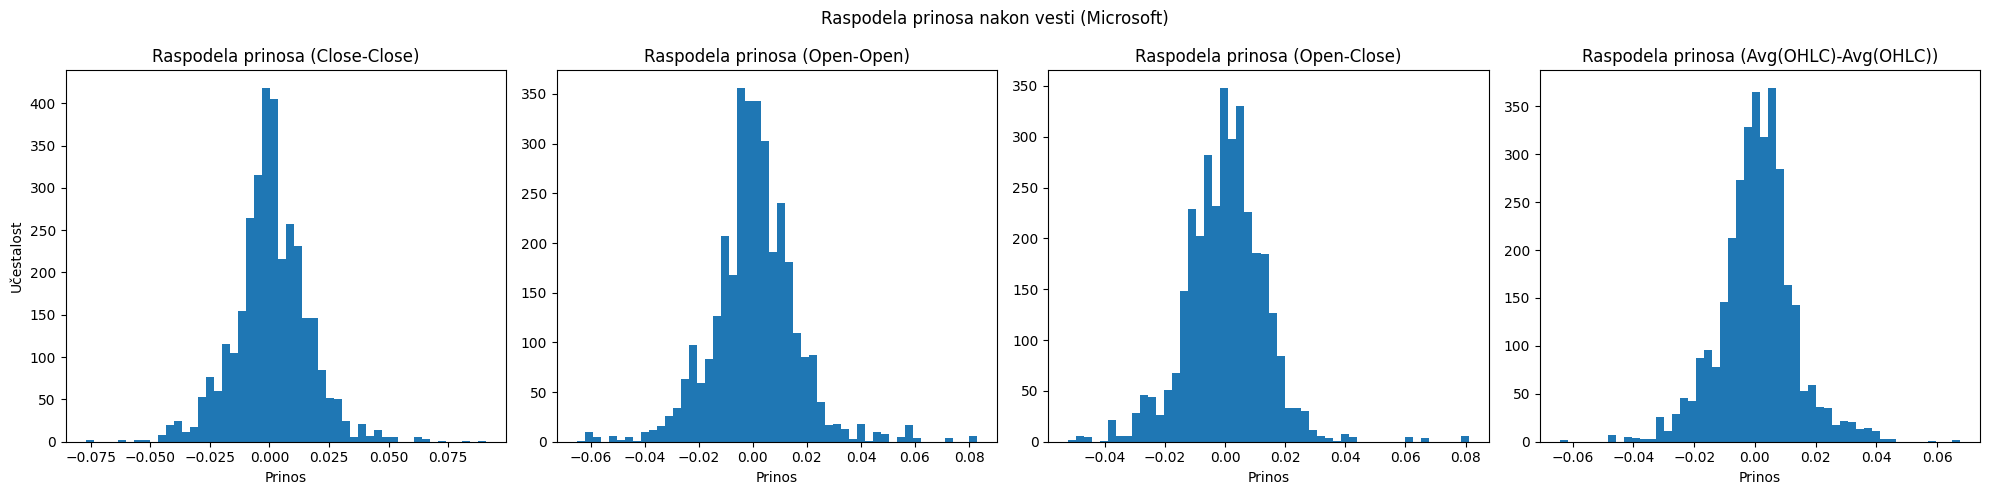

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20,5))

# Close-Close
axes[0].hist(msft_merged["return_close_close"].dropna(), bins=50)
axes[0].set_title("Raspodela prinosa (Close-Close)")
axes[0].set_xlabel("Prinos")
axes[0].set_ylabel("Učestalost")

# Open-Open
axes[1].hist(msft_merged["return_open_open"].dropna(), bins=50)
axes[1].set_title("Raspodela prinosa (Open-Open)")
axes[1].set_xlabel("Prinos")

# Open-Close
axes[2].hist(msft_merged["return_open_close"].dropna(), bins=50)
axes[2].set_title("Raspodela prinosa (Open-Close)")
axes[2].set_xlabel("Prinos")

# Avg-Avg
axes[3].hist(msft_merged["return_avg_avg"].dropna(), bins=50)
axes[3].set_title("Raspodela prinosa (Avg(OHLC)-Avg(OHLC))")
axes[3].set_xlabel("Prinos")

plt.suptitle("Raspodela prinosa nakon vesti (Microsoft)")
plt.tight_layout()
plt.show()

In [39]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [40]:
from typing import Optional
from enum import Enum
from pydantic import BaseModel, Field


class Sentiment(str, Enum):
    NEGATIVE = "negative"
    NEUTRAL = "neutral"
    POSITIVE = "positive"


class Topic(str, Enum):
    CLOUD = "azure_cloud_services"
    WINDOWS = "windows_operating_system"
    OFFICE = "office_productivity_services"
    AI = "ai_ml"
    GAMING = "xbox_gaming_business"
    ENTERPRISE = "enterprise_software"
    REGULATION = "regulation_antitrust"
    LEGAL = "legal_lawsuit"
    MACRO = "macro_economy_rates_inflation"
    MERGERS = "mna_partnerships"
    OTHER = "other"


class NewsAnnotation(BaseModel):
    """Structured annotation for Microsoft-related financial news."""

    sentiment: Optional[Sentiment] = Field(
        default=None,
        description="Overall sentiment expressed toward Microsoft in the news.",
        examples=[Sentiment.NEGATIVE]
    )

    sentiment_score: Optional[float] = Field(
        default=None,
        description="Sentiment score between -1 and 1 where -1 is very negative, 0 neutral, and 1 very positive.",
        examples=[-0.8, 0.0, 0.7]
    )

    topic: Optional[Topic] = Field(
        default=None,
        description="Main topic of the news related to Microsoft. Choose the closest single category.",
        examples=[Topic.CLOUD]
    )

In [41]:
import pandas as pd

# funkcija za spajanje title i content
def combine_title_content(row, max_chars=2000):
    title = str(row.get("title", "") or "").strip()
    content = str(row.get("content", "") or "").strip()

    if len(content) > max_chars:
        content = content[:max_chars]

    if content:
        return f"TITLE: {title}\nCONTENT: {content}"

    return f"TITLE: {title}"


msft_merged["text_for_ie"] = msft_merged.apply(combine_title_content, axis=1)

msft_merged[["text_for_ie"]].head(2)

,text_for_ie
0,TITLE: New Research: Key Drivers of Growth for...
1,TITLE: 3 ETFs To Short The Dow\nCONTENT: With ...


In [42]:
!pip -q install openai langchain langchain-openai pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.7/506.7 kB 20.7 MB/s eta 0:00:00


In [43]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

system_msg = """
You are an expert financial information extraction agent.
Determine Microsoft-targeted sentiment based on the impact on Microsoft Corporation (Microsoft, MSFT).

Return:
- sentiment: EXACTLY one of (positive, neutral, negative)
- sentiment_score: a number between -1 and 1

Rules for sentiment_score:
- -1 = extremely negative news for Microsoft
- 0 = neutral impact
- 1 = extremely positive news
- intermediate values allowed (e.g., -0.3, 0.6)

The sentiment_score must be consistent with the sentiment label.

If Microsoft is mentioned but the impact is unclear, return neutral and sentiment_score = 0.
Return null ONLY if Microsoft is not mentioned at all.
Use lowercase only.
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_msg),
    ("human", "Analyze the following Microsoft-related news:\n{text}")
])

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

ie_chain = prompt | llm.with_structured_output(NewsAnnotation)

In [44]:
from time import sleep
import pandas as pd

def tag_df_openai(
    df: pd.DataFrame,
    text_col="text_for_ie",
    sleep_sec=0.4,
    save_every=100,
    save_path=None
):
    """
    Automatska anotacija finansijskih vesti pomoću LLM modela
    za Microsoft kompaniju.

    Za svaku vest model određuje:
    - sentiment (positive, neutral, negative)
    - sentiment_score (-1 do 1)
    - glavnu temu vesti

    Funkcija takođe:
    - kontroliše brzinu API poziva (sleep)
    - periodično čuva rezultate u CSV fajl
    """

    out = df.copy()
    sentiments, scores, topics = [], [], []

    for i, txt in enumerate(out[text_col], start=1):
        try:
            res = ie_chain.invoke({"text": txt})

            sentiments.append(res.sentiment.value if res.sentiment else None)
            scores.append(res.sentiment_score if res.sentiment_score else None)
            topics.append(res.topic.value if res.topic else None)

        except Exception as e:
            sentiments.append(None)
            scores.append(None)
            topics.append(None)

        if i % 50 == 0:
            print(f"Processed {i} rows")

        if save_path and i % save_every == 0:
            out.loc[:i-1, "sentiment"] = sentiments
            out.loc[:i-1, "sentiment_score"] = scores
            out.loc[:i-1, "topic"] = topics
            out.to_csv(save_path, index=False)

        sleep(sleep_sec)

    out["sentiment"] = sentiments
    out["sentiment_score"] = scores
    out["topic"] = topics

    return out

In [ ]:
msft_tagged = tag_df_openai(
    msft_merged,
    text_col="text_for_ie",
    save_path="/content/drive/MyDrive/microsoft_news_tagged.csv"
)

Processed 50 rows
Processed 100 rows
Processed 150 rows
Processed 200 rows
Processed 250 rows
Processed 300 rows
Processed 350 rows
Processed 400 rows
Processed 450 rows
Processed 500 rows
Processed 550 rows
Processed 600 rows
Processed 650 rows
Processed 700 rows
Processed 750 rows
Processed 800 rows
Processed 850 rows
Processed 900 rows
Processed 950 rows
Processed 1000 rows
Processed 1050 rows
Processed 1100 rows
Processed 1150 rows
Processed 1200 rows
Processed 1250 rows
Processed 1300 rows
Processed 1350 rows
Processed 1400 rows
Processed 1450 rows
Processed 1500 rows
Processed 1550 rows
Processed 1600 rows
Processed 1650 rows
Processed 1700 rows
Processed 1750 rows
Processed 1800 rows
Processed 1850 rows
Processed 1900 rows
Processed 1950 rows
Processed 2000 rows
Processed 2050 rows
Processed 2100 rows
Processed 2150 rows
Processed 2200 rows
Processed 2250 rows
Processed 2300 rows
Processed 2350 rows
Processed 2400 rows
Processed 2450 rows
Processed 2500 rows
Processed 2550 rows


In [73]:
import pandas as pd

msft_tagged = pd.read_csv("/content/drive/MyDrive/microsoft_news_tagged.csv")



In [74]:
msft_tagged.columns

Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
       'sentiment_polarity', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos',
       'year', 'close_t', 'close_t1', 'open_t1', 'avg_t', 'avg_t1',
       'return_close_close', 'return_close_open', 'return_avg_avg',
       'direction_avg_avg', 'direction_close_close', 'direction_close_open',
       'text_for_ie', 'sentiment', 'sentiment_score', 'topic'],
      dtype='object')

In [76]:
msft_tagged["date"] = pd.to_datetime(msft_tagged["date"])
len(msft_tagged)

3334

In [77]:
len(msft_tagged), len(msft_merged)

(3334, 3334)

In [78]:
new_cols = [
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg",
    "direction_close_close",
    "direction_open_close",
    "direction_open_open",
    "direction_avg_avg"
]

for col in new_cols:
    msft_tagged[col] = msft_merged[col].values

In [79]:
msft_tagged[new_cols].head()

,return_close_close,return_open_close,return_open_open,return_avg_avg,direction_close_close,direction_open_close,direction_open_open,direction_avg_avg
0,0.000395,0.004361,0.003965,0.003209,UP,UP,UP,UP
1,0.090896,0.031930,0.035896,0.067536,UP,UP,UP,UP
2,-0.015728,-0.010602,-0.040151,0.024339,DOWN,DOWN,DOWN,UP
3,0.018259,0.014472,0.026328,0.000550,UP,UP,UP,UP
4,-0.002864,-0.014384,-0.005663,0.012950,DOWN,DOWN,DOWN,UP


In [81]:
msft_tagged.drop(
    columns=["return_close_open", "direction_close_open"],
    inplace=True,
    errors="ignore"
)

In [82]:
msft_tagged.columns

Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
       'sentiment_polarity', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos',
       'year', 'close_t', 'close_t1', 'open_t1', 'avg_t', 'avg_t1',
       'return_close_close', 'return_avg_avg', 'direction_avg_avg',
       'direction_close_close', 'text_for_ie', 'sentiment', 'sentiment_score',
       'topic', 'return_open_close', 'return_open_open',
       'direction_open_close', 'direction_open_open'],
      dtype='object')

In [83]:
msft_tagged[["date", "title", "sentiment", "sentiment_score", "topic"]].head(10)

,date,title,sentiment,sentiment_score,topic
0,2017-10-05,New Research: Key Drivers of Growth for Micros...,neutral,NaN,other
1,2020-03-23,3 ETFs To Short The Dow,neutral,NaN,other
2,2020-03-30,Buying What the Fed Buys,neutral,NaN,macro_economy_rates_inflation
3,2020-04-23,Dow Jones Today: Microscopic Gains Under Loomi...,neutral,NaN,macro_economy_rates_inflation
4,2020-04-24,How to Invest Your Stimulus Check,neutral,NaN,other
5,2020-05-01,Take Buffett’s Advice: 5 Vanguard Funds to Buy,neutral,NaN,other
6,2020-05-12,Not Just Fun And Games: How Esports Could Offe...,neutral,NaN,xbox_gaming_business
7,2020-05-19,"Sony, Microsoft Strike Deal on Tiny AI Chip Wi...",positive,0.7,ai_ml
8,2020-06-15,Exciting Tech ETF May Be More Defensive Than I...,positive,0.7,other
9,2020-06-19,The 3 Best Vanguard ETFs for a Long-Term Reti...,neutral,NaN,other


In [89]:
msft_tagged["sentiment"].value_counts()

,count
sentiment,
neutral,2118
positive,822
negative,360


In [87]:
msft_tagged.to_csv(
    "/content/drive/MyDrive/microsoft_news_tagged_fixed.csv",
    index=False
)

In [105]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [106]:
import pandas as pd

msft_tagged = pd.read_csv("/content/drive/MyDrive/microsoft_news_tagged_fixed.csv")

In [107]:
msft_tagged["sentiment_score"].describe()

,sentiment_score
count,1182.000000
mean,0.315719
std,0.579148
min,-0.800000
25%,-0.400000
50%,0.700000
75%,0.700000
max,0.900000


In [108]:
msft_tagged[["sentiment","sentiment_score"]].head(20)

,sentiment,sentiment_score
0,neutral,NaN
1,neutral,NaN
2,neutral,NaN
3,neutral,NaN
4,neutral,NaN
5,neutral,NaN
6,neutral,NaN
7,positive,0.7
8,positive,0.7
9,neutral,NaN


In [109]:
msft_tagged["date_only"] = pd.to_datetime(msft_tagged["date"]).dt.date

In [110]:
sent_map = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

msft_tagged["sentiment_num"] = msft_tagged["sentiment"].map(sent_map)

In [111]:
daily_sentiment_class = msft_tagged.groupby("date_only").agg(
    daily_sentiment_class=("sentiment_num", "mean"),
    news_count=("sentiment_num", "count")
).reset_index()

In [112]:
daily_sentiment_class.head(20)

,date_only,daily_sentiment_class,news_count
0,2017-10-05,0.0,1
1,2020-03-23,0.0,1
2,2020-03-30,0.0,1
3,2020-04-23,0.0,1
4,2020-04-24,0.0,1
5,2020-05-01,0.0,1
6,2020-05-12,0.0,1
7,2020-05-19,1.0,1
8,2020-06-15,1.0,1
9,2020-06-19,0.0,1


In [113]:
daily_sentiment_score = msft_tagged.groupby("date_only").agg(
    daily_sentiment_score=("sentiment_score", "mean"),
    news_count=("sentiment_score", "count")
).reset_index()

In [114]:
daily_sentiment_score.head(20)

,date_only,daily_sentiment_score,news_count
0,2017-10-05,NaN,0
1,2020-03-23,NaN,0
2,2020-03-30,NaN,0
3,2020-04-23,NaN,0
4,2020-04-24,NaN,0
5,2020-05-01,NaN,0
6,2020-05-12,NaN,0
7,2020-05-19,0.7,1
8,2020-06-15,0.7,1
9,2020-06-19,NaN,0


In [115]:
daily_sentiment = msft_tagged.groupby("date_only").agg(
    daily_sentiment_class=("sentiment_num", "mean"),
    daily_sentiment_score=("sentiment_score", "mean"),
    news_count=("title", "count"),
    return_close_close=("return_close_close", "first"),
    return_open_close=("return_open_close", "first"),
    return_open_open=("return_open_open", "first"),
    return_avg_avg=("return_avg_avg", "first")
).reset_index()

In [116]:
d = pd.to_datetime("2020-09-03").date()

daily_sentiment[daily_sentiment["date_only"] == d]

,date_only,daily_sentiment_class,daily_sentiment_score,news_count,return_close_close,return_open_close,return_open_open,return_avg_avg
17,2020-09-03,-0.5,-0.5,2,-0.014036,-0.003952,-0.039982,-0.042589


In [117]:
daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_score"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
))[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

/tmp/ipykernel_3844/172947486.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sentiment.groupby(pd.cut(


,return_close_close,return_open_close,return_open_open,return_avg_avg
daily_sentiment_score,,,,
negative,-0.000664,-0.000772,0.000239,-0.003200
neutral,-0.001341,-0.000301,0.002280,-0.000804
positive,0.001129,0.000913,0.000705,0.001741


In [118]:
daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_class"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
), observed=True)[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

,return_close_close,return_open_close,return_open_open,return_avg_avg
daily_sentiment_class,,,,
negative,-0.000620,-0.000461,0.000906,-0.003275
neutral,0.001141,0.000444,0.001624,0.001288
positive,0.000960,0.000834,0.000521,0.001628


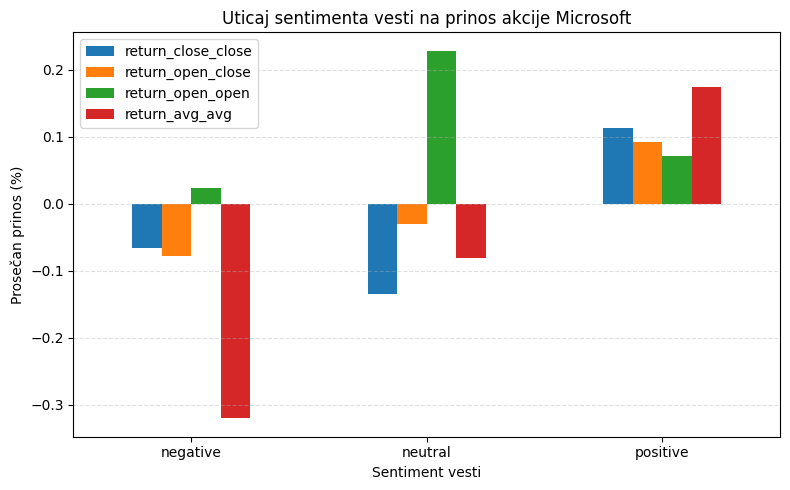

In [119]:
import matplotlib.pyplot as plt

returns_by_sentiment = daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_score"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
), observed=True)[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

# u procente
returns_by_sentiment_percent = returns_by_sentiment * 100

# plot
returns_by_sentiment_percent.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Uticaj sentimenta vesti na prinos akcije Microsoft")
plt.xlabel("Sentiment vesti")
plt.ylabel("Prosečan prinos (%)")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

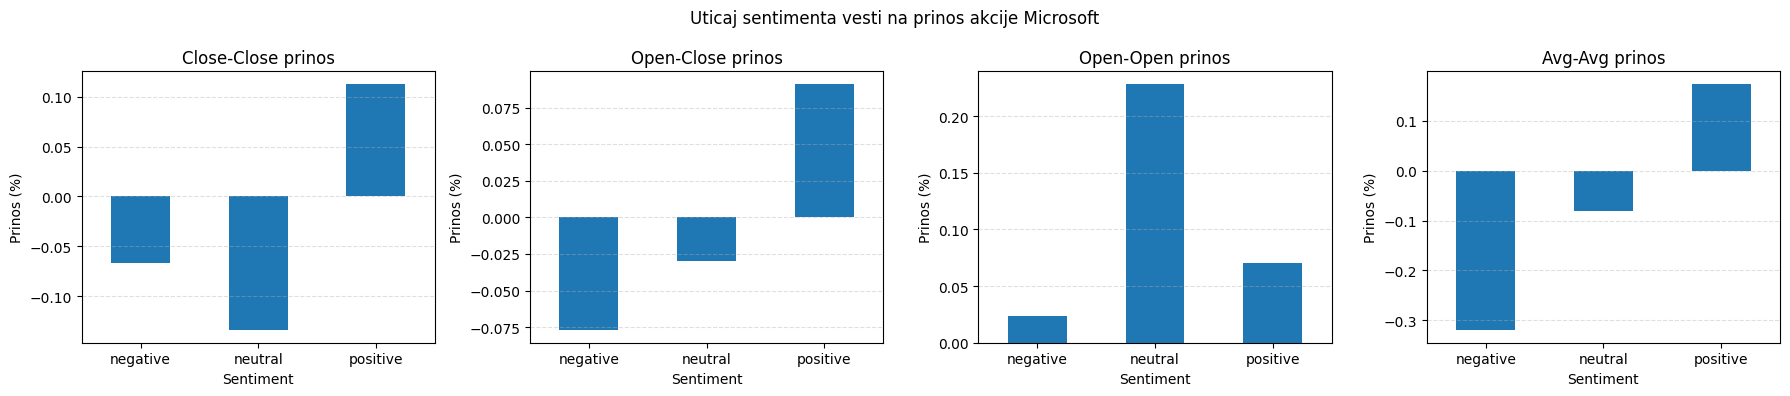

In [120]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))

# Close-Close
returns_by_sentiment_percent["return_close_close"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Close-Close prinos")

# Open-Close
returns_by_sentiment_percent["return_open_close"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Open-Close prinos")

# Open-Open
returns_by_sentiment_percent["return_open_open"].plot(kind="bar", ax=axes[2])
axes[2].set_title("Open-Open prinos")

# Avg-Avg
returns_by_sentiment_percent["return_avg_avg"].plot(kind="bar", ax=axes[3])
axes[3].set_title("Avg-Avg prinos")

for ax in axes:
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Prinos (%)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle("Uticaj sentimenta vesti na prinos akcije Microsoft")

plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

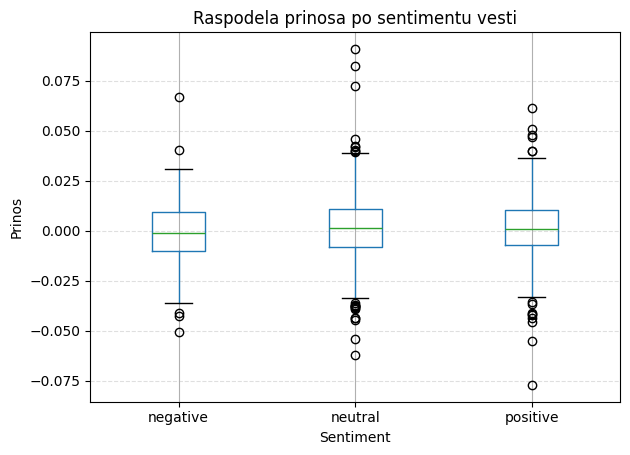

In [121]:
import matplotlib.pyplot as plt

# kopija podataka
df_daily = daily_sentiment.copy()

# formiranje grupa na osnovu daily_sentiment_class
df_daily["sentiment_group"] = pd.cut(
    df_daily["daily_sentiment_class"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
)

# boxplot
plt.figure(figsize=(6,4))

df_daily.boxplot(
    column="return_close_close",
    by="sentiment_group"
)

plt.title("Raspodela prinosa po sentimentu vesti")
plt.suptitle("")  # uklanja default naslov
plt.xlabel("Sentiment")
plt.ylabel("Prinos")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

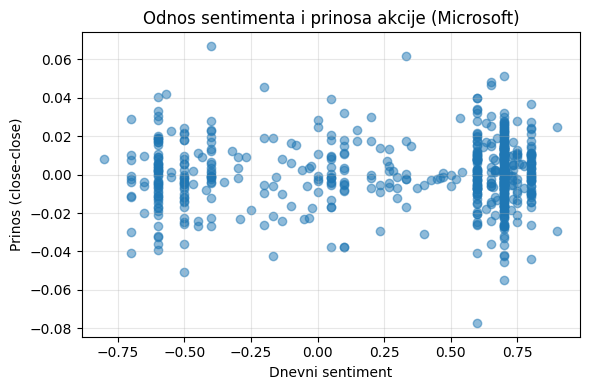

In [122]:
import matplotlib.pyplot as plt

# uklonjeno NaN
df_daily = daily_sentiment.dropna(subset=["daily_sentiment_score", "return_close_close"])

plt.figure(figsize=(6,4))

plt.scatter(
    df_daily["daily_sentiment_score"],
    df_daily["return_close_close"],
    alpha=0.5
)

plt.title("Odnos sentimenta i prinosa akcije (Microsoft)")
plt.xlabel("Dnevni sentiment")
plt.ylabel("Prinos (close-close)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()